In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split as train_test_split_s
import seaborn as sns

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from config import *
from src.models import *
from src.dataset import *
from utils import *

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"    # ?

set_seed(seed=GLOBAL_SEED)

2025-07-28 09:41:45.157773: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-28 09:41:45.188987: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-28 09:41:45.623596: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
WINDOW_SIZE = 100

In [3]:
def standardize(X, means, stds):
    return (X - means[None,:,None]) / stds[None,:,None]

In [4]:
def prepare(X, channels=CHANNELS):
    Xt = np.transpose(X, (0, 2, 1))   # [N, window, channels]
    sel = Xt[..., channels]           # отбор каналов
    return sel[..., np.newaxis].astype(np.float32)

In [5]:
emg, label = folder_extract('../' + FOLDER_PATH, exercises=EXERCISES, myo_pref=MYO_PREF)
all_g = gestures(emg, label, targets=GESTURE_INDEXES_MAIN)

train_g, _ = train_test_split(all_g, split_size=0.0, rand_seed=GLOBAL_SEED)

X, y = apply_window(train_g, window=WINDOW_SIZE, step=STEP_SIZE)

In [6]:
norm_file = f'../normalization_values/fold1_win{WINDOW_SIZE}_attention.json'
with open(norm_file, 'r') as f: 
    params = json.load(f)

X_stand = standardize(X, np.array(params['mean']), np.array(params['std']))
X = prepare(X_stand, channels=range(8))

In [7]:
X.shape

(41157, 100, 8, 1)

In [8]:
input_shape = (WINDOW_SIZE, X.shape[2], 1)

In [9]:
model = build_SAM_model(input_shape, FILTERS_BASE, KERNEL_SIZE_BASE, POOL_SIZE_BASE, P_DROPOUT_BASE, NUM_CLASSES)
model.load_weights('../' + SAVE_PATH + f'_fold1_{WINDOW_SIZE}_attention.h5')

2025-07-28 09:42:03.993755: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-07-28 09:42:03.993781: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: etri3060-H610M4-PLUS
2025-07-28 09:42:03.993785: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: etri3060-H610M4-PLUS
2025-07-28 09:42:03.993918: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:199] libcuda reported version is: 575.57.8
2025-07-28 09:42:03.993934: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:203] kernel reported version is: 575.57.8
2025-07-28 09:42:03.993937: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:309] kernel version seems to match DSO: 575.57.8


In [10]:
model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='sparse_categorical_crossentropy', metrics=['accuracy']
    )
model.evaluate(X, y, batch_size=32)

2025-07-28 09:42:04.315568: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [41157]
	 [[{{node Placeholder/_11}}]]
2025-07-28 09:42:04.315747: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [41157]
	 [[{{node Placeholder/_11}}]]


1287/1287 [==============================] - 10s 7ms/step - loss: 0.0546 - accuracy: 0.9828


[0.054601699113845825, 0.9828218817710876]

In [11]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 100, 8, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 100, 8, 48)        192       
                                                                 
 batch_normalization (BatchN  (None, 100, 8, 48)       192       
 ormalization)                                                   
                                                                 
 p_re_lu (PReLU)             (None, 100, 8, 48)        38400     
                                                                 
 spatial_dropout2d (SpatialD  (None, 100, 8, 48)       0         
 ropout2D)                                                       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 100, 4, 48)       0     

In [12]:
intermediate_output_layer = model.layers[-4]
intermediate_model = tf.keras.Model(inputs=model.input, outputs=intermediate_output_layer.output)
features = intermediate_model.predict(X)

  17/1287 [..............................] - ETA: 8s

2025-07-28 09:42:14.329358: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [41157,100,8,1]
	 [[{{node Placeholder/_10}}]]
2025-07-28 09:42:14.329519: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [41157,100,8,1]
	 [[{{node Placeholder/_10}}]]


1287/1287 [==============================] - 9s 7ms/step


In [13]:
features.shape

(41157, 100, 2, 96)

In [14]:
features.reshape(features.shape[0], -1).shape

(41157, 19200)

# PCA

Сжимаем пространство признаков до двух компонент.

In [15]:
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull

pca = PCA(2, whiten=True, svd_solver='auto', random_state=GLOBAL_SEED)

X_embedded = pca.fit_transform(features.reshape(features.shape[0], -1))

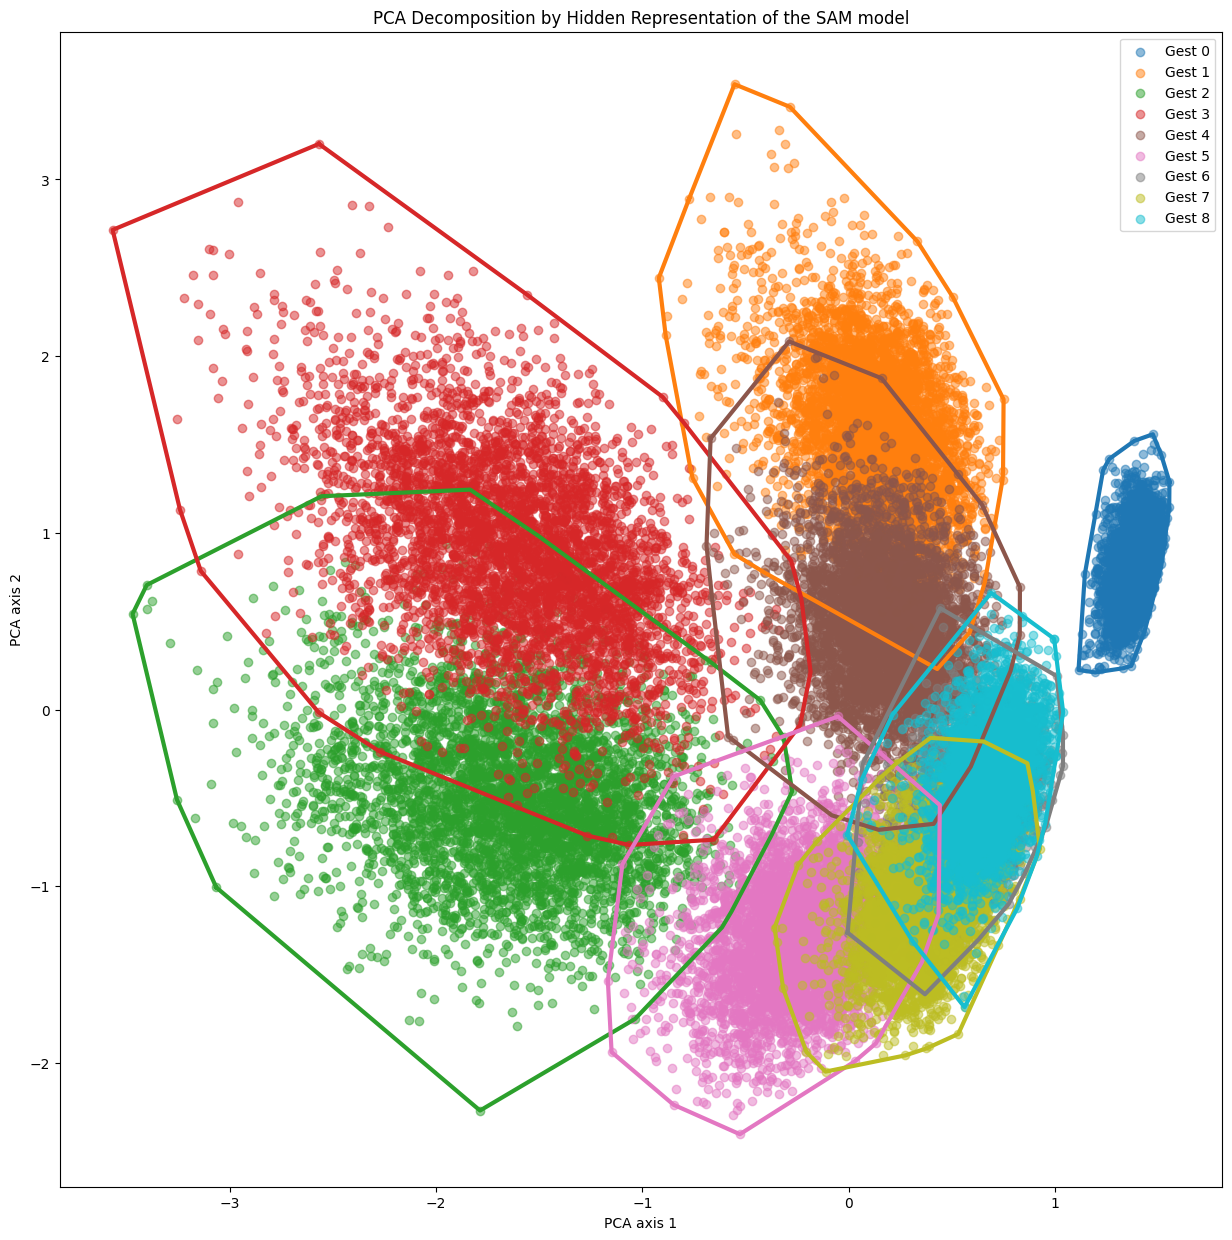

In [16]:
plt.figure(figsize=(15, 15))
colors = plt.cm.tab10(np.linspace(0, 1, len(np.unique(y))))

for i, gest_i in enumerate(np.unique(y)):
    cluster_points = X_embedded[y == gest_i]
    
    # Отрисовка точек
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Gest {gest_i}', alpha=0.5, color=colors[i])
    
    # Вычисляем выпуклую оболочку, если точек достаточно (не меньше 3)
    if cluster_points.shape[0] >= 3:
        hull = ConvexHull(cluster_points)
        # Получаем вершины оболочки
        hull_points = cluster_points[hull.vertices]
        # Замыкаем контур (возвращаемся к первой точке)
        hull_points = np.append(hull_points, hull_points[0:1, :], axis=0)
        # Рисуем контур
        plt.plot(hull_points[:, 0], hull_points[:, 1], color=colors[i], linewidth=3)
        

plt.xlabel('PCA axis 1')
plt.ylabel('PCA axis 2')

plt.title('PCA Decomposition by Hidden Representation of the SAM model')

plt.legend()
plt.show()


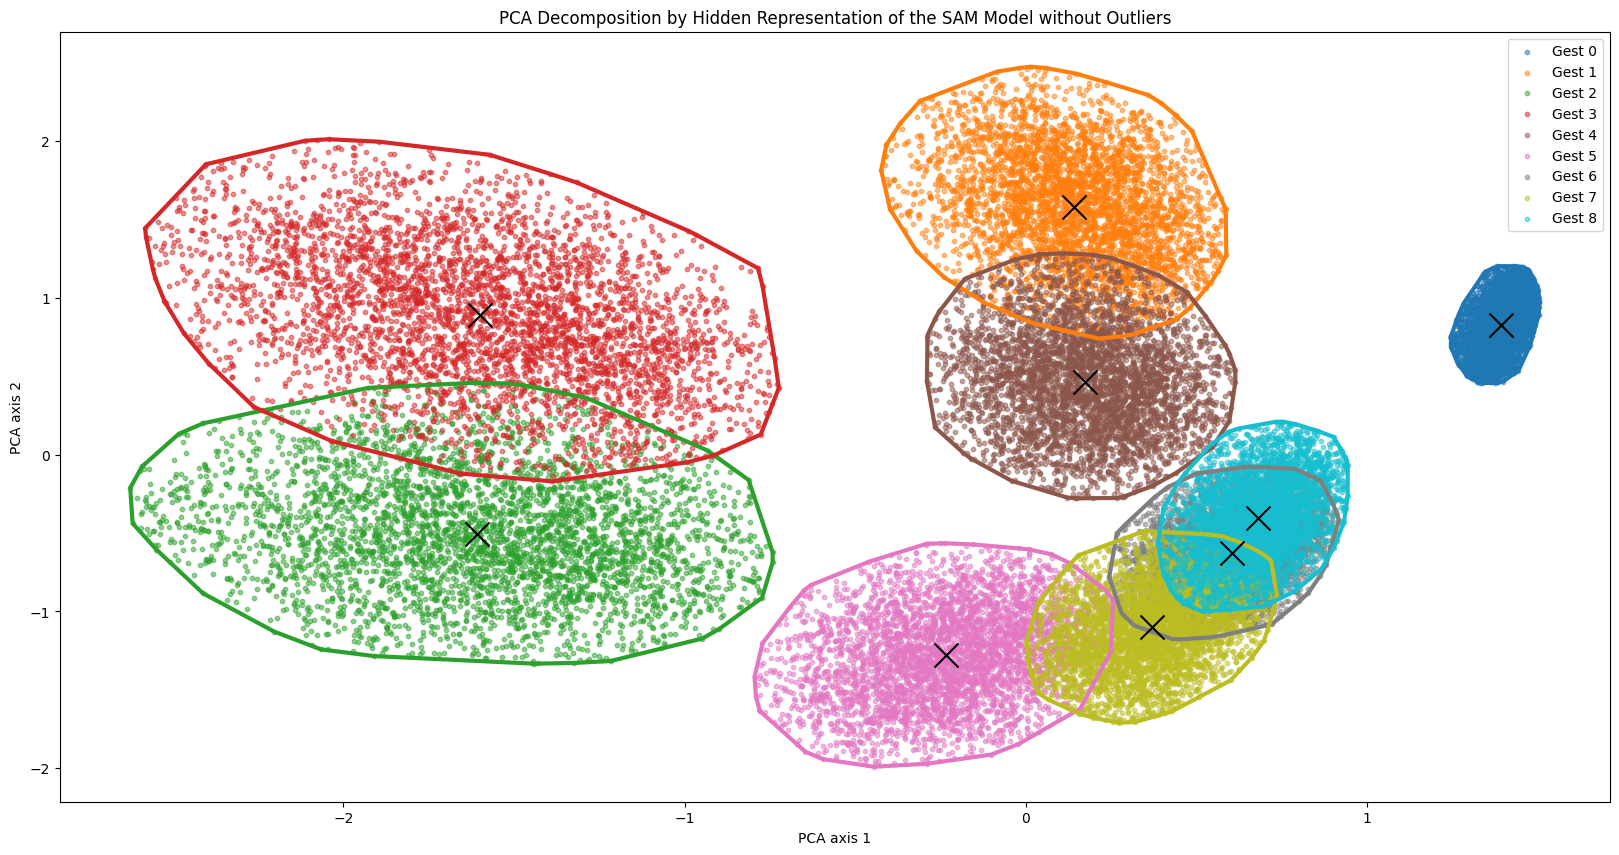

In [17]:
from sklearn.ensemble import IsolationForest


plt.figure(figsize=(20, 10))
colors = plt.cm.tab10(np.linspace(0, 1, len(np.unique(y))))

new_cluster_points = []
new_labels = []

for i, gest_i in enumerate(np.unique(y)):
    cluster_mask = (y == gest_i)
    cluster_points = X_embedded[ cluster_mask]
    global_idx = np.where(cluster_mask)[0]

    iso = IsolationForest(contamination=0.1, random_state=42)
    labels = iso.fit_predict(cluster_points)

    outlier_local_idx = np.where(labels == -1)[0]
    outlier_global_idx = global_idx[outlier_local_idx]
    clean_global_idx = np.setdiff1d(global_idx, outlier_global_idx)

    clean_cluster_points = X_embedded[clean_global_idx]
    new_cluster_points.extend(clean_cluster_points)
    new_labels.extend(clean_global_idx)
    
    center = np.mean(clean_cluster_points, axis=0)

    hull = ConvexHull(clean_cluster_points)
        # Получаем вершины оболочки
    hull_points = clean_cluster_points[hull.vertices]
        # Замыкаем контур (возвращаемся к первой точке)
    hull_points = np.append(hull_points, hull_points[0:1, :], axis=0)
        # Рисуем контур
    plt.plot(hull_points[:, 0], hull_points[:, 1], color=colors[i], linewidth=3, zorder=5)

    # Сначала рисуем точки с меньшим zorder
    plt.scatter(clean_cluster_points[:, 0], clean_cluster_points[:, 1],
                label=f'Gest {gest_i}', alpha=0.5, color=colors[i], s=10, zorder=1)

    # Потом крестики с большим zorder, чтобы они были поверх
    plt.scatter(center[0], center[1], color='black', marker='x', s=300, zorder=10)

plt.xlabel('PCA axis 1')
plt.ylabel('PCA axis 2')

plt.title('PCA Decomposition by Hidden Representation of the SAM Model without Outliers')

plt.legend()
plt.show()


## Кластеризация HDBSCAN

In [18]:
new_cluster_points = np.asarray(new_cluster_points)
new_labels = np.array(new_labels)

In [19]:
from sklearn.cluster import HDBSCAN

hdb = HDBSCAN(min_cluster_size=500)
hdb.fit(new_cluster_points)

hdb.labels_.shape == (X.shape[0],)

False

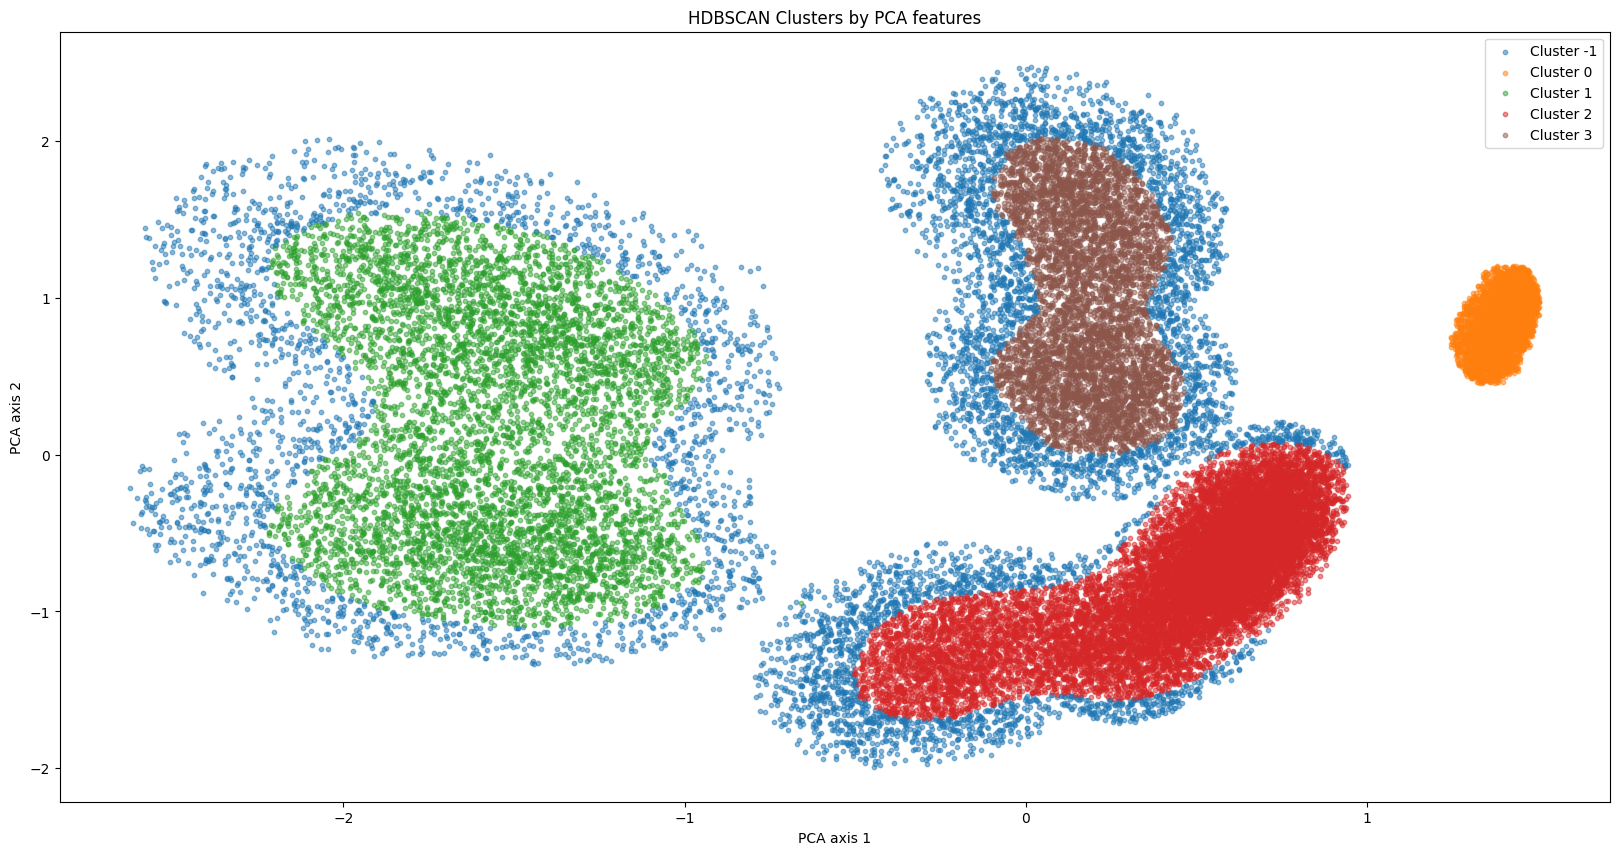

In [20]:
plt.figure(figsize=(20, 10))

for color_idx, cluster_label in enumerate(np.unique(hdb.labels_)):
    cluster_points = new_cluster_points[np.where(hdb.labels_ == cluster_label)]
    plt.scatter(cluster_points[:,0], cluster_points[:,1], label=f'Cluster {cluster_label}', alpha=0.5, color=colors[color_idx], s=10,)

plt.xlabel('PCA axis 1')
plt.ylabel('PCA axis 2')

plt.title('HDBSCAN Clusters by PCA features')

plt.legend()
plt.show()

## Определение положения данных с нового пользователя в редуцированном пространтсве

In [21]:
new_gestures_dict = {'0': np.load('../emg_recorder/data/discrete_0/emg_imu_0.npy')[:, :8]}

In [22]:
emgs, labels = apply_window(new_gestures_dict, window=WINDOW_SIZE, step=STEP_SIZE)

In [23]:
params

{'mean': [-0.8920435905456543,
  -1.0329838991165161,
  -0.9249534606933594,
  -0.8314253091812134,
  -0.8670164346694946,
  -0.9044445753097534,
  -0.8762621879577637,
  -0.954133152961731],
 'std': [14.41256332397461,
  15.780951499938965,
  8.922114372253418,
  4.837248802185059,
  8.818009376525879,
  13.813658714294434,
  11.462541580200195,
  15.283219337463379]}

In [28]:
norm_file = f'../normalization_values/fold1_win{WINDOW_SIZE}_early_fusion_full.json'
with open(norm_file, 'r') as f: 
    params = json.load(f)

X_stand_new = standardize(emgs, np.array(params['mean'][:8]), np.array(params['std'][:8]))
X_input_new = prepare(X_stand, channels=range(8))

In [32]:
features_new = intermediate_model.predict(X_input_new)

  23/1287 [..............................] - ETA: 9s

2025-07-28 09:44:19.430332: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [41157,100,8,1]
	 [[{{node Placeholder/_10}}]]
2025-07-28 09:44:19.430493: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [41157,100,8,1]
	 [[{{node Placeholder/_10}}]]


1287/1287 [==============================] - 9s 7ms/step


In [40]:
X_embedded_new = pca.transform(features_new.reshape(features_new.shape[0], -1))

In [43]:
new_cluster_points.shape

(37039, 2)

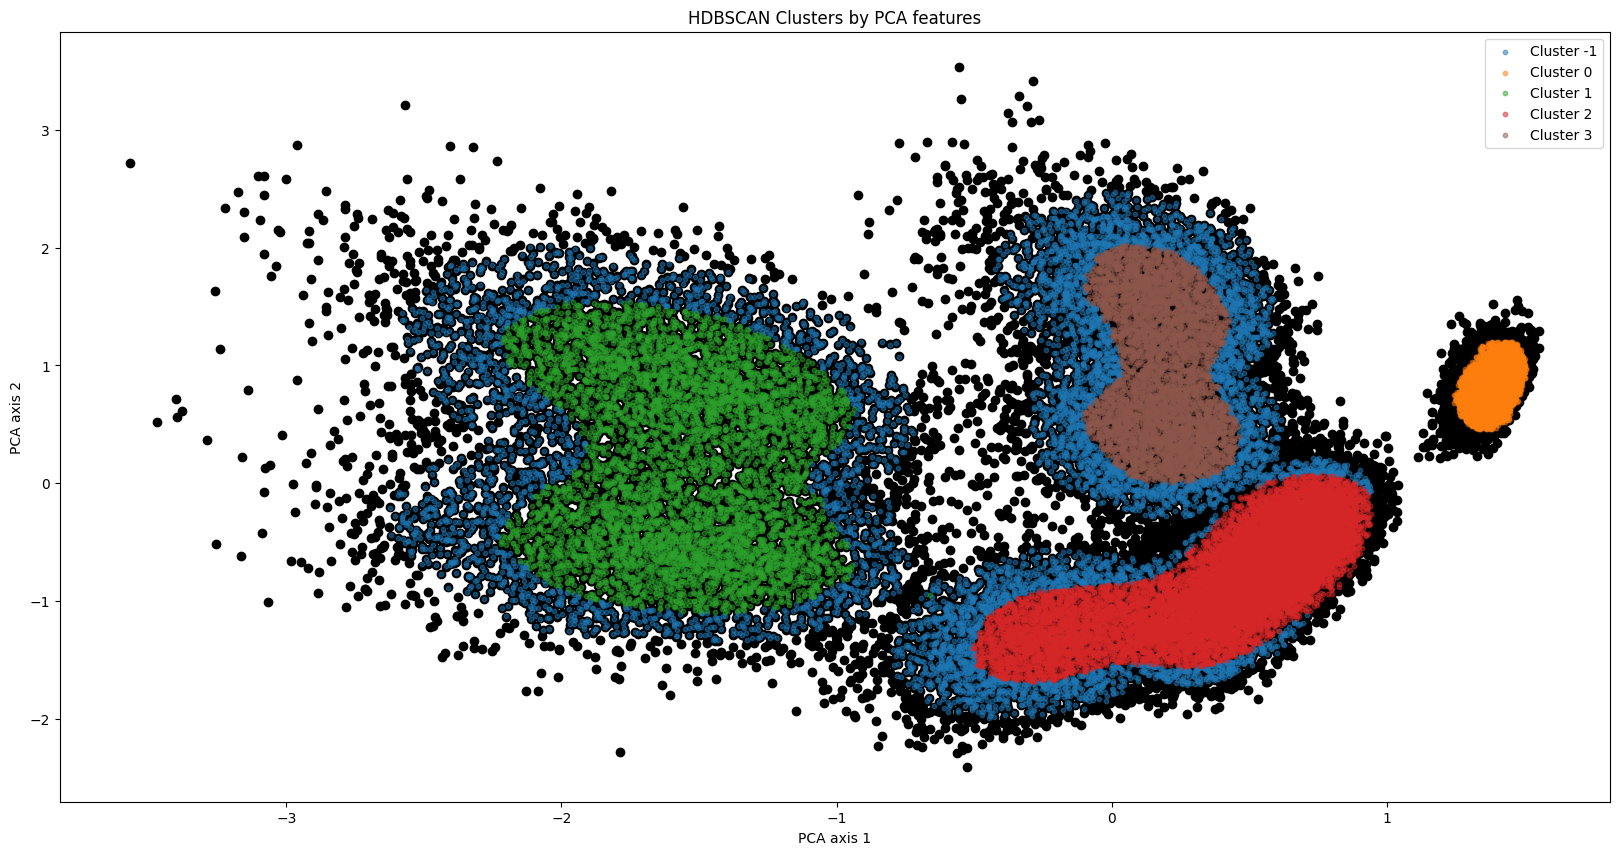

In [49]:
plt.figure(figsize=(20, 10))

plt.scatter(X_embedded_new[:,0], X_embedded_new[:, 1], color='black')

for color_idx, cluster_label in enumerate(np.unique(hdb.labels_)):
    cluster_points = new_cluster_points[np.where(hdb.labels_ == cluster_label)]
    plt.scatter(cluster_points[:,0], cluster_points[:,1], label=f'Cluster {cluster_label}', alpha=0.5, color=colors[color_idx], s=10,)

# plt.scatter(X_embedded_new[:,0], X_embedded_new[:, 1], color='black')

plt.xlabel('PCA axis 1')
plt.ylabel('PCA axis 2')

plt.title('HDBSCAN Clusters by PCA features')

plt.legend()
plt.show()